# Demo pipeline (этап 9)

Минимальный демонстрационный запуск: URL -> кандидаты -> фильтрация -> итоговые изображения.

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import sys
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
LABELS_PATH = DATA_DIR / "labels.csv"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.pipeline import run_pipeline_for_url

In [6]:
url = "https://eda.rambler.ru/media/recepty/recepty-kulichey-na-pashu-ot-klassiki-do-bystryh-variantov"
summary = run_pipeline_for_url(
    url=url,
    output_dir="results/examples",
    raw_dir="data/raw",
    mode="baseline_plus_ml",
    model_path="models/best_model.pkl",
)
summary

{'total_candidates': 212,
 'downloaded_ok': 211,
 'baseline_rejected': 10,
 'baseline_kept': 202,
 'ml_candidates': 202,
 'final_kept': 26,
 'top_reject_reasons': {'tracking_url_hint': 8,
  'probable_tracking_pixel': 7,
  'too_small': 7,
  'suspicious_keyword': 5,
  'invalid_image': 3,
  'download_failed': 1},
 'page_url': 'https://eda.rambler.ru/media/recepty/recepty-kulichey-na-pashu-ot-klassiki-do-bystryh-variantov',
 'page_id': 'eda.rambler.ru_media_recepty_recepty-kulichey-na-pashu-ot-klassik',
 'mode': 'baseline_plus_ml',
 'saved_images': 26,
 'paths_to_saved_artifacts': {'page_info': 'results\\examples\\eda.rambler.ru_media_recepty_recepty-kulichey-na-pashu-ot-klassik\\page_info.json',
  'candidates_csv': 'results\\examples\\eda.rambler.ru_media_recepty_recepty-kulichey-na-pashu-ot-klassik\\candidates.csv',
  'final_kept_csv': 'results\\examples\\eda.rambler.ru_media_recepty_recepty-kulichey-na-pashu-ot-klassik\\final_kept.csv',
  'run_log': 'results\\examples\\eda.rambler.ru_me

In [7]:
artifacts = summary.get("paths_to_saved_artifacts", {})
for key, value in artifacts.items():
    print(f"{key}: {value}")

page_info: results\examples\eda.rambler.ru_media_recepty_recepty-kulichey-na-pashu-ot-klassik\page_info.json
candidates_csv: results\examples\eda.rambler.ru_media_recepty_recepty-kulichey-na-pashu-ot-klassik\candidates.csv
final_kept_csv: results\examples\eda.rambler.ru_media_recepty_recepty-kulichey-na-pashu-ot-klassik\final_kept.csv
run_log: results\examples\eda.rambler.ru_media_recepty_recepty-kulichey-na-pashu-ot-klassik\run_log.json
final_keep_dir: results\examples\eda.rambler.ru_media_recepty_recepty-kulichey-na-pashu-ot-klassik\final_keep


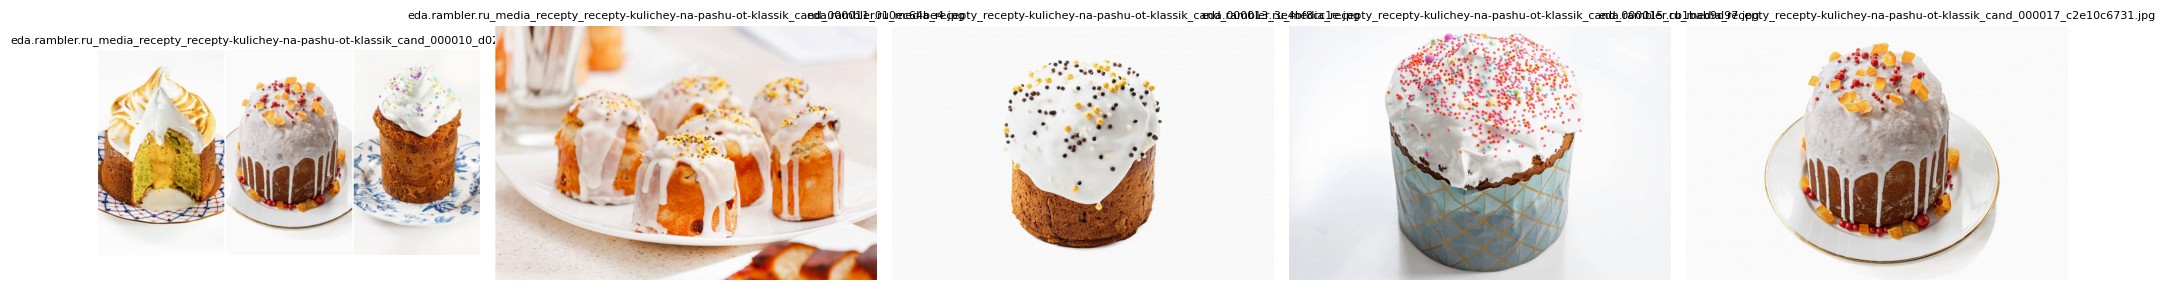

In [8]:
final_keep_dir = Path(artifacts.get("final_keep_dir", ""))
images = sorted([p for p in final_keep_dir.glob("*") if p.is_file()])[:5]

if not images:
    print("Финальные изображения не найдены.")
else:
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    if len(images) == 1:
        axes = [axes]
    for ax, img_path in zip(axes, images):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")
    plt.tight_layout()